# Analisi delle immagini, riscritto in grazia

## Importazione delle librerie



In [78]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets

In [79]:
%matplotlib widget
plt.close('all')

## Funzioni utili

### Caricamento e conversione dati

In [80]:
# conversione dei timestamp nello stesso formato tra bilancia e immagini (sarebbe il caso di sistemarlo anche nell'interfaccia...)

FORMATO_COMUNE = "%Y-%m-%d %H:%M:%S"

def bilancia_timestamp_to_common(timestamp_unix, fmt=FORMATO_COMUNE):
    """
    Timestamp bilancia (Unix epoch) -> formato comune.
    Supporta secondi (10 cifre) e millisecondi (13 cifre).
    """
    ts = float(timestamp_unix)
    if ts > 1e12:  # millisecondi
        ts /= 1000.0
    return time.strftime(fmt, time.localtime(ts))


def image_timestamp_to_common(image_name_or_timestamp, fmt=FORMATO_COMUNE):
    """
    Timestamp immagini -> formato comune.
    Accetta:
    - 'frame_YYYYMMDD_HHMMSS.png'
    - 'YYYYMMDD_HHMMSS'
    - 'YYYY-MM-DD_HH-MM-SS' (nome cartella sessione)
    """
    s = str(image_name_or_timestamp)
    base = os.path.basename(s)

    m1 = re.search(r"(\d{8}_\d{6})", base)
    if m1:
        t = time.strptime(m1.group(1), "%Y%m%d_%H%M%S")
        return time.strftime(fmt, t)

    m2 = re.search(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})", base)
    if m2:
        t = time.strptime(m2.group(1), "%Y-%m-%d_%H-%M-%S")
        return time.strftime(fmt, t)

    raise ValueError("Formato timestamp immagine non riconosciuto")

In [81]:
# caricamento dati dalle immagini

base_img_folder = "data/raw"

def load_images_from_folder(folder):
    """
    Carica tutte le immagini PNG da una cartella, restituendo una lista di immagini e i loro timestamp in formato comune.
    """
    images = []
    timestamps = []
    for filename in os.listdir(folder):
        if filename.endswith(".png"):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                images.append(img)
                timestamps.append(image_timestamp_to_common(filename))
    return images, timestamps

def load_images_from_folders(folders):
    """
    Carica immagini da più cartelle, restituendo liste aggregate di immagini e timestamp.
    """
    all_images = []
    all_timestamps = []
    for folder in folders:
        images, timestamps = load_images_from_folder(folder)
        all_images.extend(images)
        all_timestamps.extend(timestamps)
    return all_images, all_timestamps

def sort_images_and_timestamps(images, timestamps):
    """
    Ordina immagini e timestamp in base ai timestamp.
    """
    combined = list(zip(timestamps, images))
    combined.sort(key=lambda x: x[0])
    sorted_timestamps, sorted_images = zip(*combined)
    return list(sorted_images), list(sorted_timestamps)


In [82]:
# carica timestamp, rate, thickness dalla bilancia

def load_bilancia_data(file_path):
    """
    Carica dati dalla bilancia, restituendo liste di timestamp (formato comune), rate e thickness.
    """
    timestamps = []
    rates = []
    thicknesses = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                ts_common = bilancia_timestamp_to_common(parts[0])
                timestamps.append(ts_common)
                rates.append(float(parts[1]))
                thicknesses.append(float(parts[2]))
    return timestamps, rates, thicknesses

In [83]:
def extract_common_timestamp_points(image_timestamps, bilancia_timestamps, max_diff_seconds=1.0):
    """
    Trova timestamp comuni tra immagini e bilancia, restituendo indici corrispondenti.
    """
    common_image_indices = []
    common_bilancia_indices = []
    
    for i, img_ts in enumerate(image_timestamps):
        img_time = time.strptime(img_ts, FORMATO_COMUNE)
        img_seconds = time.mktime(img_time)
        
        for j, bil_ts in enumerate(bilancia_timestamps):
            bil_time = time.strptime(bil_ts, FORMATO_COMUNE)
            bil_seconds = time.mktime(bil_time)
            
            if abs(img_seconds - bil_seconds) <= max_diff_seconds:
                common_image_indices.append(i)
                common_bilancia_indices.append(j)
                break  # Assumiamo un match unico per ogni immagine
    
    return common_image_indices, common_bilancia_indices

def interpolate_timestamps(image_timestamps, bilancia_timestamps, bilancia_values):
    """
    Interpola i valori della bilancia per i timestamp delle immagini.
    Restituisce una lista di valori interpolati corrispondenti ai timestamp delle immagini.
    """
    image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
    bilancia_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in bilancia_timestamps]
    
    interpolated_values = np.interp(image_seconds, bilancia_seconds, bilancia_values)
    return interpolated_values


### Elaborazione immagini

In [84]:
def moving_average_images(images, window_size):
    """
    Applica una media mobile alle immagini, restituendo una nuova lista di immagini filtrate.
    """

    if window_size == 1:
        return images  # nessun filtro se la finestra è 1

    moving_avg_imgs = []

    for i in range(len(images)):
        start_idx = max(0, i - window_size//2 + 1)
        end_idx = min(len(images), i + window_size//2 + 1)
        window_imgs = images[start_idx:end_idx]
        moving_avg_img = np.mean(window_imgs, axis=0).astype(np.uint8)
        moving_avg_imgs.append(moving_avg_img)

    return moving_avg_imgs

def extract_roi_from_images(images, roi_center, roi_radius):
    """
    Estrae una regione di interesse (ROI) circolare da ogni immagine, restituendo una lista di immagini ROI.
    """
    roi_images = []

    for img in images:
        mask = np.zeros_like(img, dtype=np.uint8)
        cv2.circle(mask, roi_center, roi_radius, 255, -1)
        roi_img = cv2.bitwise_and(img, img, mask=mask)
        roi_images.append(roi_img)

    return roi_images

def compute_difference_from_reference(images, reference_image):
    """
    Calcola la differenza assoluta tra ogni immagine e un'immagine di riferimento, restituendo una lista di immagini differenza.
    """
    difference_images = []

    for img in images:
        diff_img = cv2.absdiff(img, reference_image)
        difference_images.append(diff_img)

    return difference_images

def compute_average_intensity(images):
    """
    Calcola l'intensità media di ogni immagine, restituendo una lista di valori di intensità media.
    """
    avg_intensities = []

    for img in images:
        avg_intensity = np.mean(img)
        avg_intensities.append(avg_intensity)

    return avg_intensities

def extract_line_profile(images, x0, y0, x1, y1):
    """
    Estrae il profilo di intensità lungo una linea definita da (x0, y0) a (x1, y1) per ogni immagine, restituendo una lista di array di profili.
    """
    line_profiles = []

    for img in images:
        line_profile = cv2.line(img.copy(), (x0, y0), (x1, y1), 255, 1)
        line_profiles.append(line_profile)

    return line_profiles

def extract_line_profiles_circle(images, center, radius, num_profiles=10):
    """
    Estrae i line profile lungo diametri di una circonferenza definita da un centro e un raggio, restituendo una lista di array di profili.
    """

    line_profiles = []
    angles = np.linspace(0, 2 * np.pi, num_profiles, endpoint=False)

    for img in images:
        profiles_for_image = []
        for angle in angles:
            x0 = int(center[0] + radius * np.cos(angle))
            y0 = int(center[1] + radius * np.sin(angle))
            x1 = int(center[0] - radius * np.cos(angle))
            y1 = int(center[1] - radius * np.sin(angle))
            line_profile = cv2.line(img.copy(), (x0, y0), (x1, y1), 255, 1)
            profiles_for_image.append(line_profile)
        line_profiles.append(profiles_for_image)

    return line_profiles


In [85]:
class RoiSelectorWidget:
    def __init__(self, image):
        self.image = image
        self.roi_center = (image.shape[1] // 2, image.shape[0] // 2)
        self.roi_radius = min(image.shape) // 4

        with plt.ioff():
            self.fig, self.ax = plt.subplots()
            self.ax.imshow(image, cmap='gray')
            self.circle = plt.Circle(self.roi_center, self.roi_radius, color='r', fill=False)
            self.ax.add_patch(self.circle)
            self.ax.set_title("Clicca con sinistro per spostare, destro per ridimensionare")

        self.cid_click = self.fig.canvas.mpl_connect('button_press_event', self.on_click)

    def on_click(self, event):
        # se tasto sinistro, cambia il centro
        if event.button == 1:
            self.roi_center = (int(event.xdata), int(event.ydata))
            self.update_circle()
        
        # se tasto destro, cambia il raggio
        elif event.button == 3:
            dx = event.xdata - self.roi_center[0]
            dy = event.ydata - self.roi_center[1]
            self.roi_radius = int(sqrt(dx**2 + dy**2))
            self.update_circle()

    def update_circle(self):
        self.circle.center = self.roi_center
        self.circle.radius = self.roi_radius
        self.fig.canvas.draw()
    
    def draw(self):
        self.fig.show()
    
    @property
    def roi(self):
        return self.roi_center, self.roi_radius

## Test e visualizzazione

In [86]:

available_dirs = [d for d in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, d))]

available_times_secs = [time.mktime(time.strptime(image_timestamp_to_common(d), FORMATO_COMUNE)) for d in available_dirs]

sorted_dirs = [d for _, d in sorted(zip(available_times_secs, available_dirs))]
sorted_times = [time.mktime(time.strptime(image_timestamp_to_common(d), FORMATO_COMUNE)) for d in sorted_dirs]


In [87]:
start_time_widget = widgets.Dropdown(options=sorted_dirs, description='Inizio:')

display(start_time_widget)

Dropdown(description='Inizio:', options=('2026-04-20_18-56-25', '2026-04-20_18-56-39', '2026-04-20_19-01-21', …

In [92]:
start_time = start_time_widget.value

start_time_seconds = time.mktime(time.strptime(image_timestamp_to_common(start_time), FORMATO_COMUNE))

# carica tutte le cartelle con t> start time
folders = [d for d in sorted_dirs if time.mktime(time.strptime(image_timestamp_to_common(d), FORMATO_COMUNE)) >= start_time_seconds]

print("Cartelle caricate:")
for d in folders:
    print(f"- {d}")

Cartelle caricate:
- 2026-04-27_17-28-37
- 2026-04-27_17-28-40
- 2026-04-27_17-34-45
- 2026-04-27_17-34-48
- 2026-04-27_17-36-39


In [93]:
# carica dati bilancia dalle cartelle selezionate
bilancia_paths = [os.path.join(base_img_folder, d, "data/points.txt") for d in folders]
bilancia_data = [load_bilancia_data(p) for p in bilancia_paths if os.path.exists(p)]

bilancia_timestamps = [i[0] for i in bilancia_data]
bilancia_rates = [i[1] for i in bilancia_data]
bilancia_thicknesses = [i[2] for i in bilancia_data]

print("Dati bilancia caricati:")
print(f"- Timestamps: {len(bilancia_timestamps)}")
print(f"- Rates: {len(bilancia_rates)}")
print(f"- Thicknesses: {len(bilancia_thicknesses)}")

Dati bilancia caricati:
- Timestamps: 3
- Rates: 3
- Thicknesses: 3


In [94]:
# combina i dati caricati

bilancia_timestamps, rates, thicknesses = [], [], []

for data in bilancia_data:
    bilancia_timestamps.extend(data[0])

    rates.extend(data[1])

    t = data[2]

    if len(thicknesses) > 0 and len(t) > 0 and thicknesses[-1] != t[0]:
        t = np.array(t)
        t += thicknesses[-1] - t[0]

    thicknesses.extend(t)

bilancia_times = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in bilancia_timestamps]


In [95]:
imgs_list = [load_images_from_folder(os.path.join(base_img_folder, d, "images")) for d in folders if os.path.exists(os.path.join(base_img_folder, d, "images"))]

imgs_list_sorted = []
imgs_times = []

for imgs, times in imgs_list:
    t = sort_images_and_timestamps(imgs, times)
    if len(t) == 0:
        continue
    sorted_imgs, sorted_times = t
    imgs_list_sorted.append(sorted_imgs)
    imgs_times.extend(sorted_times)

imgs_times = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in imgs_times]

In [96]:
ref_imgs = [np.mean(imgs[:10], axis=0).astype(np.uint8) for imgs in imgs_list_sorted]

diff_imgs_list = [compute_difference_from_reference(imgs, ref) for imgs, ref in zip(imgs_list_sorted, ref_imgs)]


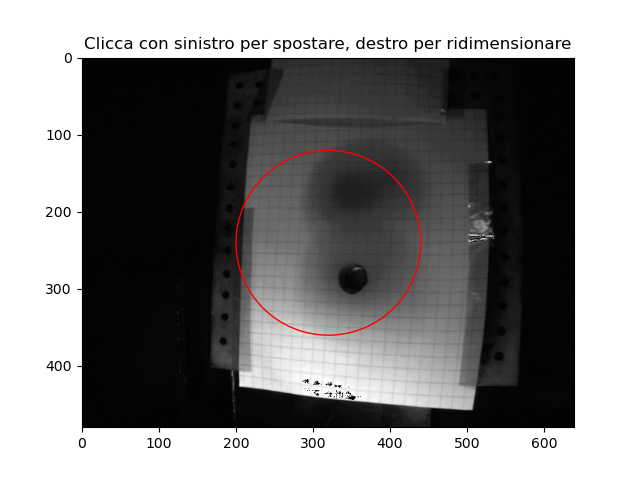

In [97]:
roi_selector = RoiSelectorWidget(ref_imgs[0] * 3)
roi_selector.draw()

In [102]:
roi_center, roi_radius = roi_selector.roi

roi_diffs_list = [extract_roi_from_images(diff_imgs, roi_center, roi_radius) for diff_imgs in diff_imgs_list]

means_list = [compute_average_intensity(roi_diffs) for roi_diffs in roi_diffs_list]

means = []

for mean in means_list:

    if len(means) > 0:
        delta = mean[0] - means[-1]
        mean = np.array(mean) - delta
    
    means.extend(list(mean))


In [103]:
print(len(means), len(imgs_times), len(bilancia_times))

787 435 968


In [104]:
tmax = min(max(imgs_times), max(bilancia_times))

# seleziona solo i dati fino a tmax
imgs_times = [t for t in imgs_times if t <= tmax]
bilancia_times = [t for t in bilancia_times if t <= tmax]

means = means[:len(imgs_times)]
thicknesses = thicknesses[:len(bilancia_times)]


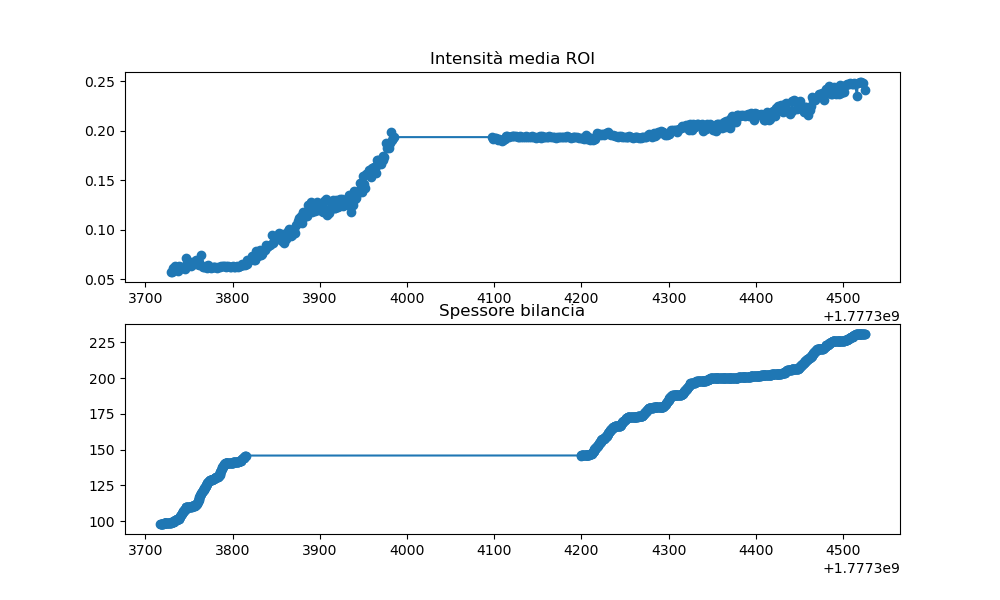

In [105]:
# plotta due subplot per dati bilancia e immagini

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
ax = plt.gca()
plt.plot(imgs_times, means, "-o")
plt.title("Intensità media ROI")


plt.subplot(2, 1, 2, sharex=ax)
plt.plot(bilancia_times, thicknesses, "-o")
plt.title("Spessore bilancia")
plt.show()
